## 1. Import recovery libraries and verify upstream evidence


In [1]:
import sys
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import Bounds, LinearConstraint, milp
from scipy.sparse import lil_matrix

sys.path.insert(0, "..")
from common_metrics import require, repeated_nt_score

DATA_DIR = Path("output")


def sha256_file(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

from validation import verify_stage, validate_schedule
for upstream in range(4):
    verify_stage(upstream)


## 2. Load the verified schedule and specification


In [2]:
def first_existing(paths):
    for path in paths:
        if Path(path).is_file():
            return Path(path)
    return None


canonical_path = first_existing([DATA_DIR / "canonical_schedule.csv", "canonical_schedule.csv"])
specification_path = first_existing([DATA_DIR / "model_specification.json", "model_specification.json"])
optimized_path = first_existing([DATA_DIR / "optimized_schedule_fairness_aware.csv", "optimized_schedule_fairness_aware.csv"])
require(None not in (canonical_path, specification_path, optimized_path), "Run notebooks 00-03 first.")



canonical_sha256 = sha256_file(canonical_path)
specification_sha256 = sha256_file(specification_path)
optimized_sha256 = sha256_file(optimized_path)

model_specification = json.loads(specification_path.read_text(encoding="utf-8"))
require(model_specification.get("canonical_sha256") == canonical_sha256, "Specification/canonical mismatch.")

historical = pd.read_csv(canonical_path)
optimized = pd.read_csv(optimized_path)
for frame in [historical, optimized]:
    frame["week_start"] = pd.to_datetime(frame["week_start"], errors="raise")
    frame["week_end"] = pd.to_datetime(frame["week_end"], errors="raise")
    for column in ["nT", "rotation_group", "rotation_round"]:
        frame[column] = pd.to_numeric(frame[column], errors="raise").astype(int)
require(optimized["schedule_source"].eq("optimized_fairness_aware").all(), "Expected the fairness-aware schedule.")

parameters = model_specification["parameters"]
derived_maps = model_specification["derived_maps"]
rotation_groups = [int(g) for g in parameters["rotation_groups"]]
weekly_staffing_floor = int(parameters["weekly_staffing_floor"])
weekly_h24_required = int(parameters["weekly_h24_required"])
maximum_annual_workload = int(parameters["maximum_annual_workload"])
group_by_nt = {int(nt): int(g) for nt, g in derived_maps["group_by_nt"].items()}
primary_group = {p: int(g) for p, g in derived_maps["primary_group_by_pharmacy"].items()}
group_sizes = {int(g): int(s) for g, s in derived_maps["group_sizes"].items()}
nt_occurrences = {int(nt): int(c) for nt, c in derived_maps["nt_occurrences"].items()}
h24_cycle_bounds = {int(g): {k: int(v) for k, v in b.items()} for g, b in parameters["h24_cycle_bounds_by_group"].items()}
nt_values = sorted(nt_occurrences)


secondary_group_by_pharmacy = derived_maps.get("secondary_group_by_pharmacy", {})

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
print("Assignments / weeks / pharmacies:", len(optimized), optimized["week_id"].nunique(), optimized["pharmacy_id"].nunique())
print("Historical candidate evidence (from real historical events only):", secondary_group_by_pharmacy)


Assignments / weeks / pharmacies: 923 53 123
Historical candidate evidence (from real historical events only): {'P0076': {'primary_group': 5, 'historical_secondary_groups': [7], 'evidence': [{'week_id': '2026-W28', 'nT': 21, 'shift_type': 'H24'}]}}


## 3. Verify lineage and the optimized base schedule


In [3]:
week_columns = ["week_id", "week_start", "week_end", "nT", "rotation_group", "rotation_round"]
weeks = optimized[week_columns].drop_duplicates().sort_values("week_start").reset_index(drop=True)
require(historical[week_columns].drop_duplicates().sort_values("week_start").reset_index(drop=True).equals(weeks),
        "Optimized week metadata does not match the canonical schedule.")

repeated_matches, repeated_pairs = repeated_nt_score(optimized, weeks)




pattern_schedule = optimized[["nT", "pharmacy_id", "shift_type", "access_mode"]].drop_duplicates()
active_by_nt = {nt: set(pattern_schedule.loc[pattern_schedule["nT"].eq(nt), "pharmacy_id"]) for nt in nt_values}
h24_by_nt = {
    nt: set(pattern_schedule.loc[pattern_schedule["nT"].eq(nt) & pattern_schedule["shift_type"].eq("H24"), "pharmacy_id"])
    for nt in nt_values
}
group_members = {g: sorted(p for p, ag in primary_group.items() if ag == g) for g in rotation_groups}
annual_total_workload = optimized.groupby("pharmacy_id").size().reindex(sorted(primary_group), fill_value=0).astype(int)
annual_h24_workload = optimized.loc[optimized["shift_type"].eq("H24")].groupby("pharmacy_id").size().reindex(sorted(primary_group), fill_value=0).astype(int)
pattern_h24_workload = pattern_schedule.loc[pattern_schedule["shift_type"].eq("H24")].groupby("pharmacy_id").size().reindex(sorted(primary_group), fill_value=0).astype(int)

weekly_total = optimized.groupby("week_id").size()
weekly_h24 = optimized.loc[optimized["shift_type"].eq("H24")].groupby("week_id").size()


h24_bounds_valid = all(
    h24_cycle_bounds[primary_group[p]]["minimum"] <= int(pattern_h24_workload[p]) <= h24_cycle_bounds[primary_group[p]]["maximum"]
    for p in primary_group
)

validation = pd.DataFrame([
    ("Repeated nT patterns are exact", repeated_matches == repeated_pairs),
    ("Weekly staffing floor is satisfied", bool(weekly_total.ge(weekly_staffing_floor).all())),
    ("Weekly H24 requirement is satisfied", bool(weekly_h24.eq(weekly_h24_required).all())),
    ("Annual workload maximum is satisfied", int(annual_total_workload.max()) <= maximum_annual_workload),
    ("H24 cycle bounds are satisfied", h24_bounds_valid),
], columns=["validation", "passed"])
require(validation["passed"].all(), validation.loc[~validation.passed, "validation"].tolist())
validation["status"] = np.where(validation["passed"], "PASS", "FAIL")
display(validation[["validation", "status"]])

validate_schedule(optimized, historical, model_specification)


Out[3]: {'assignments': 923, 'hard_constraints': 'PASS'}


,validation,status
0,Repeated nT patterns are exact,PASS
1,Weekly staffing floor is satisfied,PASS
2,Weekly H24 requirement is satisfied,PASS
3,Annual workload maximum is satisfied,PASS
4,H24 cycle bounds are satisfied,PASS


## 4. Test every single-pharmacy unavailability


In [4]:
recovery_policy = model_specification["robustness_policy"]
require(recovery_policy["event_unit"] == "eligible pharmacy-nT pair", "Unsupported robustness event unit.")
require(recovery_policy["preserve_base_h24_annual_bounds"] and not recovery_policy["preserve_optimized_total_range"], "Recovery policy mismatch.")
require(model_specification["project_scope"]["absence_scenarios_are_hypothetical"], "Absences are simulated, not observed data.")
optimized_h24_annual_min = int(annual_h24_workload.min())
optimized_h24_annual_max = int(annual_h24_workload.max())


def solve_h24_recovery(unavailable_pharmacy, unavailable_nt, active_sets):
    '''Re-solve H24 assignment within one group after an absence changes who's active.
    A small MILP: binary "does pharmacy p do H24 at pattern nt" variables, one row per
    nT (must hit the required H24 count) and two rows per pharmacy (its H24 cycle bounds
    and its annual H24 range), objective favors keeping today's H24 pharmacies H24.'''
    group = group_by_nt[unavailable_nt]
    group_nts = [nt for nt in nt_values if group_by_nt[nt] == group]
    members = group_members[group]
    bounds = h24_cycle_bounds[group]

    eligible_pairs = [(p, nt) for nt in group_nts for p in members if p in active_sets[nt]]
    pair_index = {pair: i for i, pair in enumerate(eligible_pairs)}
    variable_count = len(eligible_pairs)
    rows, lower, upper = [], [], []

    for nt in group_nts:
        row = {pair_index[(p, nt)]: 1.0 for p in members if (p, nt) in pair_index}
        rows.append(row); lower.append(float(weekly_h24_required)); upper.append(float(weekly_h24_required))
    for p in members:
        cycle_row = {pair_index[(p, nt)]: 1.0 for nt in group_nts if (p, nt) in pair_index}
        rows.append(cycle_row); lower.append(float(bounds["minimum"])); upper.append(float(bounds["maximum"]))
        annual_row = {pair_index[(p, nt)]: float(nt_occurrences[nt]) for nt in group_nts if (p, nt) in pair_index}
        rows.append(annual_row); lower.append(float(optimized_h24_annual_min)); upper.append(float(optimized_h24_annual_max))

    matrix = lil_matrix((len(rows), variable_count), dtype=float)
    for r, coefficients in enumerate(rows):
        for c, v in coefficients.items():
            matrix[r, c] = v

    
    
    base_h24_pairs = {(p, nt) for nt in group_nts for p in h24_by_nt[nt]}
    objective = np.array([-1.0 if pair in base_h24_pairs else 1.0 for pair in eligible_pairs], dtype=float)
    result = milp(
        c=objective, integrality=np.ones(variable_count, dtype=int),
        bounds=Bounds(np.zeros(variable_count), np.ones(variable_count)),
        constraints=LinearConstraint(matrix.tocsr(), np.array(lower), np.array(upper)),
    )
    if not result.success:
        return {"feasible": False, "changed_count": None, "change_details": "", "selected": None}
    selected = {pair for pair, v in zip(eligible_pairs, result.x) if v > 0.5}
    changed = sorted(base_h24_pairs.symmetric_difference(selected), key=lambda item: (item[1], item[0]))
    details = "; ".join(f"{'ADD' if pair in selected else 'REMOVE'}:{pair[0]}@nT={pair[1]}" for pair in changed)
    return {"feasible": True, "changed_count": len(changed), "change_details": details, "selected": selected}


def secondary_eligibility_match(unavailable_nt, group):
    '''Return the historically-precedented substitute pharmacy for this exact (group, nT),
    if the candidate evidence built in notebook 02 has one -- else None.'''
    for candidate, info in secondary_group_by_pharmacy.items():
        if group in info["historical_secondary_groups"]:
            evidenced_nts = {e["nT"] for e in info["evidence"] if e["nT"] == unavailable_nt}
            if evidenced_nts:
                return candidate
    return None


response_rows = []
recovery_plans = []
base_total_load = annual_total_workload.to_dict()
recovery_bounds = (optimized_h24_annual_min, optimized_h24_annual_max)
for nt in nt_values:
    group = group_by_nt[nt]
    members = group_members[group]
    base_active = set(active_by_nt[nt])
    for unavailable_pharmacy in members:
        was_active = unavailable_pharmacy in base_active
        was_h24 = unavailable_pharmacy in h24_by_nt[nt]
        response_active = base_active - {unavailable_pharmacy}
        active_replacement = ""
        if was_active and len(response_active) < weekly_staffing_floor:
            candidates = [p for p in members if p != unavailable_pharmacy and p not in response_active
                          and base_total_load[p] + nt_occurrences[nt] <= maximum_annual_workload]
            
            
            candidates.sort(key=lambda p: (base_total_load[p],p))
        else:
            candidates = [""]
        if not candidates:candidates = [""]
        recoverable = False
        last_error = ""
        for replacement in candidates:
            response_active = (base_active - {unavailable_pharmacy}) | ({replacement} if replacement else set())
            active_sets = {t:set(v) for t,v in active_by_nt.items()}
            active_sets[nt] = response_active
            h24_recovery = solve_h24_recovery(unavailable_pharmacy, nt, active_sets) if was_h24 else {
                "feasible":True, "changed_count":0, "change_details":"", "selected":None}
            h24_sets = {t:set(v) for t,v in h24_by_nt.items()}
            if was_h24 and h24_recovery["feasible"]:
                for t in nt_values:
                    if group_by_nt[t] == group:
                        h24_sets[t] = {p for p, tt in h24_recovery["selected"] if tt == t}
            active_replacement = replacement
            try:
                if not h24_recovery["feasible"]:raise ValueError("H24 recovery MILP infeasible")
                validate_schedule(optimized,historical,model_specification,active_overrides=active_sets,
                                  h24_overrides=h24_sets,absence=(unavailable_pharmacy,nt),
                                  recovery_h24_bounds=recovery_bounds)
                recoverable = True
                break
            except ValueError as error:
                last_error = str(error)
        staffing_feasible = len(response_active) >= weekly_staffing_floor
        needs_authorization = bool(was_active and not recoverable)
        secondary_candidate = (secondary_eligibility_match(nt, group) or "") if needs_authorization else ""
        candidate_feasible = False
        candidate_reason = ""
        if secondary_candidate:
            candidate_sets = {t:set(v) for t,v in active_sets.items()}
            candidate_sets[nt].add(secondary_candidate)
            
            
            try:
                if not h24_recovery["feasible"]:raise ValueError("H24 recovery infeasible")
                validate_schedule(optimized,historical,model_specification,active_overrides=candidate_sets,
                                  h24_overrides=h24_sets,absence=(unavailable_pharmacy,nt),
                                  approved_cross_pairs={(secondary_candidate,nt)},
                                  recovery_h24_bounds=recovery_bounds)
                candidate_feasible = True
                candidate_reason = "All modeled constraints pass with the exact historical eligibility exception; availability and authorization unverified."
            except ValueError as error:
                candidate_reason = str(error)
        if not was_active:status = "NO_CHANGE_REQUIRED"
        elif not recoverable and secondary_candidate:status = "HISTORICAL_CANDIDATE_REQUIRES_APPROVAL"
        elif not recoverable:status = "MANUAL_CROSS_GROUP_DECISION_REQUIRED"
        elif was_h24 and active_replacement:status = "SAME_GROUP_ACTIVE_REPLACEMENT_AND_H24_REOPTIMIZATION"
        elif was_h24:status = "H24_REOPTIMIZATION_WITHIN_GROUP"
        elif active_replacement:status = "SAME_GROUP_ACTIVE_REPLACEMENT"
        else:status = "SPARE_CAPACITY_ABSORBS_ABSENCE"
        event_id = f"{nt}:{unavailable_pharmacy}"
        response_rows.append({
            "event_id":event_id,"nT":int(nt),"rotation_group":int(group),
            "unavailable_pharmacy_id":unavailable_pharmacy,"group_size":len(members),
            "affected_week_count":int(nt_occurrences[nt]),
            "was_scheduled_active":bool(was_active),"was_scheduled_H24":bool(was_h24),
            "same_group_active_replacement_id":active_replacement,
            "staffing_feasible_after_response":bool(staffing_feasible),
            "H24_reoptimization_feasible":bool(h24_recovery["feasible"]),
            "H24_changed_pattern_assignments":h24_recovery["changed_count"],
            "H24_change_details":h24_recovery["change_details"],
            "hard_constraints_recoverable_within_group":bool(recoverable),
            "cross_group_authorization_required":needs_authorization,
            "secondary_eligible_candidate_from_history":secondary_candidate,
            "candidate_modeled_constraints_pass":bool(candidate_feasible),
            "candidate_validation_reason":candidate_reason,
            "same_group_validation_failure":last_error if not recoverable else "",
            "response_status":status})
        
        recovery_plans.append({"event_id":event_id,"absence":{"pharmacy_id":unavailable_pharmacy,"nT":int(nt)},
            "same_group_recoverable":bool(recoverable),"approval_required":needs_authorization,
            "active_replacement":active_replacement,"historical_candidate":secondary_candidate,
            "candidate_modeled_constraints_pass":bool(candidate_feasible),
            "h24_by_nt":{str(t):sorted(h24_sets[t]) for t in nt_values if group_by_nt[t]==group}})
response_plan = pd.DataFrame(response_rows).sort_values(["nT","unavailable_pharmacy_id"]).reset_index(drop=True)
print("Pattern-level scenarios tested:",len(response_plan))
print(response_plan.response_status.value_counts())


Pattern-level scenarios tested: 738
response_status
MANUAL_CROSS_GROUP_DECISION_REQUIRED                    289
SPARE_CAPACITY_ABSORBS_ABSENCE                          240
SAME_GROUP_ACTIVE_REPLACEMENT                           112
H24_REOPTIMIZATION_WITHIN_GROUP                          48
SAME_GROUP_ACTIVE_REPLACEMENT_AND_H24_REOPTIMIZATION     24
HISTORICAL_CANDIDATE_REQUIRES_APPROVAL                   17
NO_CHANGE_REQUIRED                                        8
Name: count, dtype: int64


## 5. Robustness results


{
  "tested_pattern_absences": 738,
  "scheduled_active_absences": 730,
  "no_change_required": 8,
  "recoverable_within_group": 424,
  "historical_candidates_requiring_approval": 17,
  "historical_candidates_passing_modeled_constraints": 17,
  "manual_cases_without_candidate": 289,
  "total_requiring_human_intervention": 306,
  "H24_reoptimizations_feasible": 126,
  "H24_reoptimizations_tested": 126
}


,rotation_group,group_size,tested_scenarios,scheduled_active_absences,recoverable_within_group,historical_candidates_requiring_approval,manual_without_candidate,total_requiring_human_intervention
0,1,17,102,102,0,0,102,102
1,2,18,108,104,104,0,0,0
2,3,18,108,104,104,0,0,0
3,4,17,102,102,0,0,102,102
4,5,18,108,108,108,0,0,0
5,6,18,108,108,108,0,0,0
6,7,17,102,102,0,17,85,102


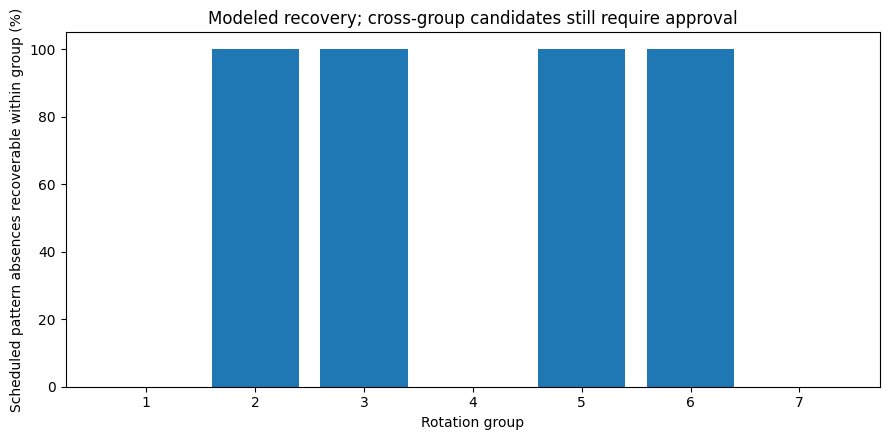

In [5]:
scheduled_events = response_plan.loc[response_plan["was_scheduled_active"]]
h24_events = response_plan.loc[response_plan["was_scheduled_H24"]]
recoverable_scheduled = int(scheduled_events["hard_constraints_recoverable_within_group"].sum())
historical_candidates = int(scheduled_events["secondary_eligible_candidate_from_history"].ne("").sum())
manual_total = int(scheduled_events["cross_group_authorization_required"].sum())
manual_without_candidate = manual_total - historical_candidates
overall_results = {
    "tested_pattern_absences":int(len(response_plan)),
    "scheduled_active_absences":int(len(scheduled_events)),
    "no_change_required":int((~response_plan.was_scheduled_active).sum()),
    "recoverable_within_group":recoverable_scheduled,
    "historical_candidates_requiring_approval":historical_candidates,
    "historical_candidates_passing_modeled_constraints":int(scheduled_events.candidate_modeled_constraints_pass.sum()),
    "manual_cases_without_candidate":manual_without_candidate,
    "total_requiring_human_intervention":manual_total,
    "H24_reoptimizations_feasible":int(h24_events.H24_reoptimization_feasible.sum()),
    "H24_reoptimizations_tested":int(len(h24_events))}
require(recoverable_scheduled + manual_total == len(scheduled_events), "Recovery/manual partition mismatch.")
require(historical_candidates + manual_without_candidate == manual_total, "Manual subtype partition mismatch.")
print(json.dumps(overall_results,indent=2))
group_summary = response_plan.groupby(["rotation_group","group_size"]).agg(
    tested_scenarios=("unavailable_pharmacy_id","size"),
    scheduled_active_absences=("was_scheduled_active","sum")).reset_index()
for name,series in {
    "recoverable_within_group":scheduled_events.groupby("rotation_group").hard_constraints_recoverable_within_group.sum(),
    "historical_candidates_requiring_approval":scheduled_events[scheduled_events.secondary_eligible_candidate_from_history.ne("")].groupby("rotation_group").size(),
    "manual_without_candidate":scheduled_events[scheduled_events.cross_group_authorization_required & scheduled_events.secondary_eligible_candidate_from_history.eq("")].groupby("rotation_group").size(),
    "total_requiring_human_intervention":scheduled_events.groupby("rotation_group").cross_group_authorization_required.sum(),
}.items():group_summary[name] = group_summary.rotation_group.map(series).fillna(0).astype(int)
display(group_summary)
fig,ax=plt.subplots(figsize=(9,4.5))
ax.bar(group_summary.rotation_group.astype(str),100*group_summary.recoverable_within_group/group_summary.scheduled_active_absences)
ax.set(ylim=(0,105),xlabel="Rotation group",ylabel="Scheduled pattern absences recoverable within group (%)",title="Modeled recovery; cross-group candidates still require approval")
fig.tight_layout();plt.show()


## 6. Human approval boundary


In [6]:
authorization_template = response_plan.loc[response_plan.cross_group_authorization_required,
    ["event_id","nT","rotation_group","unavailable_pharmacy_id","group_size",
     "secondary_eligible_candidate_from_history","candidate_modeled_constraints_pass"]].copy()
for column in ["authorized_substitute_pharmacy_id","authorization_status","authorization_reason","approved_by","approval_reference"]:
    authorization_template[column] = ""
pre_filled_from_history = response_plan.loc[response_plan.secondary_eligible_candidate_from_history.ne(""),
    ["event_id","nT","rotation_group","unavailable_pharmacy_id","secondary_eligible_candidate_from_history",
     "candidate_modeled_constraints_pass","candidate_validation_reason"]].copy()
print(f"Historical candidates needing approval: {len(pre_filled_from_history)}")
print(f"Total events needing a human decision: {len(authorization_template)}")
display(pre_filled_from_history)


Historical candidates needing approval: 17
Total events needing a human decision: 306


,event_id,nT,rotation_group,unavailable_pharmacy_id,secondary_eligible_candidate_from_history,candidate_modeled_constraints_pass,candidate_validation_reason
352,21:P0107,21,7,P0107,P0076,True,All modeled constraints pass with the exact hi...
353,21:P0108,21,7,P0108,P0076,True,All modeled constraints pass with the exact hi...
354,21:P0109,21,7,P0109,P0076,True,All modeled constraints pass with the exact hi...
355,21:P0110,21,7,P0110,P0076,True,All modeled constraints pass with the exact hi...
356,21:P0111,21,7,P0111,P0076,True,All modeled constraints pass with the exact hi...
357,21:P0112,21,7,P0112,P0076,True,All modeled constraints pass with the exact hi...
358,21:P0113,21,7,P0113,P0076,True,All modeled constraints pass with the exact hi...
359,21:P0114,21,7,P0114,P0076,True,All modeled constraints pass with the exact hi...
360,21:P0115,21,7,P0115,P0076,True,All modeled constraints pass with the exact hi...
361,21:P0116,21,7,P0116,P0076,True,All modeled constraints pass with the exact hi...


## 7. Export robustness evidence


In [7]:



response_plan.to_csv(DATA_DIR / "single_absence_response_plan.csv", index=False)
group_summary.to_csv(DATA_DIR / "robustness_summary.csv", index=False)
authorization_template.to_csv(DATA_DIR / "authorized_substitutions_template.csv", index=False)
pre_filled_from_history.to_csv(DATA_DIR / "secondary_eligibility_candidates.csv", index=False)

(DATA_DIR / "recovery_pattern_plans.json").write_text(json.dumps(recovery_plans,indent=2))
robustness_evidence = {
    "evidence_type": "single_absence_robustness_derived_from_optimized_schedule",
    "canonical_sha256": canonical_sha256,
    "model_specification_sha256": specification_sha256,
    "optimized_schedule_sha256": optimized_sha256,
    "results": overall_results,
    "group_summary": group_summary.to_dict(orient="records"),
    "policies": {
        "same_group_recovery_preferred": True,
        "all_cross_group_candidates_require_human_approval": True,
        "recovery_unit": "pharmacy-nT, affecting every occurrence; H24 changes may span the group cycle",
        "all_same_group_successes_materialized_and_validated": True,
        "optimal_total_workload_range_locked_during_recovery": False,
        "base_H24_annual_min_max_preserved_during_recovery": True,
        "secondary_eligibility_limited_to_exact_historical_precedent": True,
        "cross_group_substitution_otherwise_not_inferred": True,
        "staffing_floor_relaxed_automatically": False,
    },
}
Path(DATA_DIR / "robustness_evidence.json").write_text(json.dumps(robustness_evidence, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved: output/single_absence_response_plan.csv, robustness_summary.csv, authorized_substitutions_template.csv,")
print("       secondary_eligibility_candidates.csv, robustness_evidence.json")

from validation import write_stage
write_stage(4, ['output/stage_00_manifest.json', 'output/stage_01_manifest.json', 'output/stage_02_manifest.json', 'output/stage_03_manifest.json'], ['output/single_absence_response_plan.csv', 'output/robustness_summary.csv', 'output/authorized_substitutions_template.csv', 'output/secondary_eligibility_candidates.csv', 'output/robustness_evidence.json', 'output/recovery_pattern_plans.json'])


Saved: output/single_absence_response_plan.csv, robustness_summary.csv, authorized_substitutions_template.csv,
       secondary_eligibility_candidates.csv, robustness_evidence.json
